# Comparative Analysis of Machine Learning Algorithms for Fake News Detection
### Complete Final Notebook - Analysis + Figures + Saved Models (All-In-One)

This single notebook does everything, with no duplicate training:
- Bias-aware preprocessing (removes source-identifying artifacts)
- Hyperparameter tuning (RandomizedSearchCV) - no manually picked settings
- 10-fold cross-validation throughout - no manual train/test split
- All 3 analyses: Baseline (TF-IDF), Feature Fusion (+stylometric), Proposed Ensemble
- Overfitting/underfitting checks at every stage
- Error metrics (Log Loss, Brier Score, MSE, RMSE)
- Every figure auto-saved as a 300 DPI PNG into `figures/`, ready for your thesis
- Final trained models saved into `saved_model/`, ready for your Streamlit app

**Run every cell in order (Run All recommended). This is computationally heavy and may take 30-90+ minutes on the full dataset - let it run in the background.**

## STEP 1: Import Libraries

In [19]:
import re
import string
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import (
    StratifiedKFold, RandomizedSearchCV, cross_validate, cross_val_predict
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    log_loss, brier_score_loss, mean_squared_error
)

sns.set(style="darkgrid")

# create output folders (safe to run even if they already exist)
os.makedirs("figures", exist_ok=True)
os.makedirs("saved_model", exist_ok=True)

print("Step 1 complete: all libraries imported, figures/ and saved_model/ folders ready")

Step 1 complete: all libraries imported, figures/ and saved_model/ folders ready


## STEP 2: Define Text Processing Functions
These are also used later by the Streamlit app, so they must stay consistent.

In [20]:
def remove_source_artifacts(text):
    """Bias-aware preprocessing: strips publisher signatures like
    'WASHINGTON (Reuters) -' so models can't cheat by learning source
    formatting instead of genuine deceptive content."""
    text = str(text)
    text = re.sub(r"\b[A-Z][A-Za-z\s]*\(Reuters\)\s*-+\s*", "", text)
    text = re.sub(r"\(Reuters\)", "", text)
    text = re.sub(r"\b[A-Z][A-Za-z\s]*\(AP\)\s*-+\s*", "", text)
    text = re.sub(r"\(AP\)", "", text)
    return text

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

def stylometric_features_row(text):
    text = str(text)
    char_count = len(text)
    words = text.split()
    word_count = len(words)
    exclaim_count = text.count("!")
    question_count = text.count("?")
    capital_ratio = sum(1 for c in text if c.isupper()) / (char_count + 1)
    avg_word_length = char_count / (word_count + 1)
    return [char_count, word_count, exclaim_count, question_count,
            capital_ratio, avg_word_length]

print("Step 2 complete: text processing functions defined")

Step 2 complete: text processing functions defined


## STEP 3: Load the Dataset

In [21]:
if os.path.exists("data/Fake.csv") and os.path.exists("data/True.csv"):
    fake_df = pd.read_csv("data/Fake.csv")
    true_df = pd.read_csv("data/True.csv")
    fake_df["label"] = 0
    true_df["label"] = 1
    print("Fake news articles:", fake_df.shape)
    print("Real news articles:", true_df.shape)
    df = pd.concat([fake_df, true_df], axis=0)
    df["content"] = df["title"].astype(str) + " " + df["text"].astype(str)
    df = df[["content", "label"]]
elif os.path.exists("data/fake_or_real_news.csv"):
    raw = pd.read_csv("data/fake_or_real_news.csv")
    raw["label"] = raw["label"].map({"FAKE": 0, "REAL": 1})
    raw["content"] = raw["title"].astype(str) + " " + raw["text"].astype(str)
    df = raw[["content", "label"]]
else:
    raise FileNotFoundError("Put Fake.csv+True.csv or fake_or_real_news.csv in data/ folder.")

df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print("\nCombined dataset shape:", df.shape)
print(df["label"].value_counts())
df.head()

Fake news articles: (23481, 5)
Real news articles: (21417, 5)

Combined dataset shape: (44898, 2)
label
0    23481
1    21417
Name: count, dtype: int64


,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,0
1,Trump drops Steve Bannon from National Securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,0
4,Donald Trump heads for Scotland to reopen a go...,1


## STEP 4: Visualize Class Distribution (Figure 3.2)

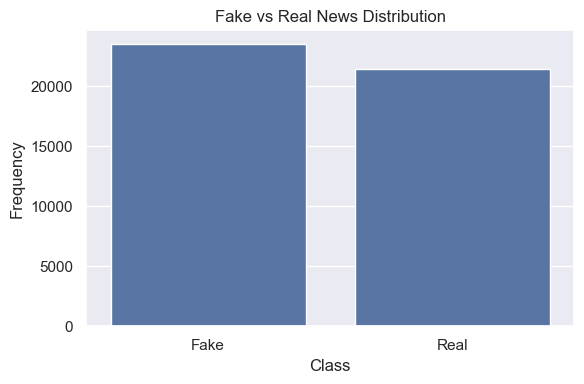

Saved: figures/fig_3_2_class_distribution.png


In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x="label", data=df)
plt.xticks([0,1], ["Fake","Real"])
plt.title("Fake vs Real News Distribution")
plt.xlabel("Class"); plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("figures/fig_3_2_class_distribution.png", dpi=300)
plt.show()
print("Saved: figures/fig_3_2_class_distribution.png")

## STEP 5: Bias-Aware Preprocessing + Text Cleaning
Source artifacts are removed FIRST, before general cleaning, so models cannot cheat by learning source formatting instead of genuine content.

In [23]:
df["content_debiased"] = df["content"].apply(remove_source_artifacts)
reuters_count = int(df["content"].str.contains(r"\(Reuters\)", regex=True).sum())
print(f"Articles that originally contained '(Reuters)': {reuters_count} out of {len(df)}")

df["clean_content"] = df["content_debiased"].apply(clean_text)
print("\nSample cleaned (debiased) text:")
print(df["clean_content"].iloc[0][:300])

Articles that originally contained '(Reuters)': 21256 out of 44898

Sample cleaned (debiased) text:
ben stein calls out th circuit court committed a ‘coup d’état’ against the constitution st century wire says ben stein reputable professor from pepperdine university also of some hollywood fame appearing in tv shows and films such as ferris bueller s day off made some provocative statements on judge


---
# ANALYSIS 1: BASELINE (TF-IDF Word Features Only)

## STEP 6: TF-IDF Feature Extraction

In [24]:
tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
X = tfidf.fit_transform(df["clean_content"])
y = df["label"]
print("TF-IDF feature matrix shape:", X.shape)

TF-IDF feature matrix shape: (44898, 5000)


## STEP 7: Extract Stylometric Features and Fuse (prepared here, used in Analysis 2)

In [25]:
style_features = df["content_debiased"].apply(
    lambda t: pd.Series(stylometric_features_row(t),
                         index=["char_count","word_count","exclaim_count",
                                "question_count","capital_ratio","avg_word_length"])
)
print(style_features.describe())

scaler = MinMaxScaler()
style_scaled = scaler.fit_transform(style_features)
X_fused = hstack([X, csr_matrix(style_scaled)]).tocsr()
print("\nFused feature matrix shape:", X_fused.shape)
print("(5000 TF-IDF word features + 6 stylometric style features = 5006 total)")

         char_count    word_count  exclaim_count  question_count  \
count  44898.000000  44898.000000   44898.000000    44898.000000   
mean    2530.371241    414.756470       0.488374        0.720500   
std     2174.274961    351.781212       1.528085        1.831436   
min       31.000000      2.000000       0.000000        0.000000   
25%     1300.250000    213.000000       0.000000        0.000000   
50%     2252.000000    372.000000       0.000000        0.000000   
75%     3172.000000    523.000000       0.000000        1.000000   
max    51893.000000   8148.000000     133.000000       94.000000   

       capital_ratio  avg_word_length  
count   44898.000000     44898.000000  
mean        0.054873         6.104664  
std         0.058434         0.899914  
min         0.000000         4.625000  
25%         0.032335         5.884434  
50%         0.040486         6.087277  
75%         0.054187         6.282192  
max         0.844262        99.666667  

Fused feature matrix shape

## STEP 8: Shared Tuning + 10-Fold CV Setup
Defines the hyperparameter search space and a reusable function that tunes each model with RandomizedSearchCV, then rigorously evaluates it with 10-fold cross-validation - checking overfitting/underfitting via train-vs-test fold scores. This function is reused for both Baseline and Fused analyses below, so the same rigorous process is applied consistently.

In [26]:
param_distributions = {
    "Logistic Regression": {"C": [0.01, 0.1, 1, 10, 100]},
    "Naive Bayes": {"alpha": [0.01, 0.1, 0.5, 1, 2]},
    "Random Forest": {"n_estimators": [100, 200, 300], "max_depth": [None, 20, 40]},
    "SVM": {"C": [0.01, 0.1, 1, 10]},
    "Passive Aggressive": {"C": [0.01, 0.1, 1, 10]},
}

def fresh_models():
    return {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Naive Bayes": MultinomialNB(),
        "Random Forest": RandomForestClassifier(random_state=42),
        "SVM": LinearSVC(max_iter=2000),
        "Passive Aggressive": PassiveAggressiveClassifier(max_iter=1000, random_state=42),
    }

cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

def tune_and_validate(X_data, label):
    print(f"--- Tuning + 10-Fold CV: {label} ---")
    models = fresh_models()
    tuned = {}
    results = {}

    for name, model in models.items():
        print(f"  Tuning {name} ...")
        search = RandomizedSearchCV(model, param_distributions[name], n_iter=5, cv=3,
                                     scoring="accuracy", random_state=42, n_jobs=-1)
        search.fit(X_data, y)
        tuned[name] = search.best_estimator_

        scores = cross_validate(search.best_estimator_, X_data, y, cv=cv10,
                                 scoring=["accuracy", "f1", "precision", "recall"],
                                 return_train_score=True, n_jobs=-1)
        train_acc = scores["train_accuracy"].mean() * 100
        test_acc = scores["test_accuracy"].mean() * 100
        gap = round(train_acc - test_acc, 2)
        verdict = ("Possible OVERFITTING" if gap > 5 else
                   ("Possible UNDERFITTING" if test_acc < 80 else "Good fit"))

        results[name] = {
            "Accuracy": test_acc, "F1 Score": scores["test_f1"].mean() * 100,
            "Precision": scores["test_precision"].mean() * 100,
            "Recall": scores["test_recall"].mean() * 100,
            "Train Acc": round(train_acc, 2), "Gap": gap, "Verdict": verdict,
        }
        print(f"    {name}: Test={test_acc:.2f}% F1={results[name]['F1 Score']:.2f}% "
              f"Train={train_acc:.2f}% Gap={gap}% -> {verdict}")

    return results, tuned

print("Step 8 complete: tuning + validation function ready")

Step 8 complete: tuning + validation function ready


## STEP 9: Run Baseline Tuning + 10-Fold Cross-Validation (Table 4.1)

In [27]:
baseline_results, baseline_tuned = tune_and_validate(X, "Baseline (TF-IDF only)")
baseline_df = pd.DataFrame(baseline_results).T
print("\n=== BASELINE RESULTS (Table 4.1) ===")
baseline_df

--- Tuning + 10-Fold CV: Baseline (TF-IDF only) ---
  Tuning Logistic Regression ...
    Logistic Regression: Test=98.65% F1=98.58% Train=99.46% Gap=0.81% -> Good fit
  Tuning Naive Bayes ...
    Naive Bayes: Test=92.75% F1=92.32% Train=92.96% Gap=0.21% -> Good fit
  Tuning Random Forest ...


c:\Users\ayush\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
7 fits failed out of a total of 15.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\ayush\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\ayush\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\ayush\AppData\Local\Programs\Python\Python310\lib\site-packages\

    Random Forest: Test=98.69% F1=98.62% Train=99.98% Gap=1.29% -> Good fit
  Tuning SVM ...


c:\Users\ayush\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


    SVM: Test=98.78% F1=98.72% Train=99.72% Gap=0.94% -> Good fit
  Tuning Passive Aggressive ...


c:\Users\ayush\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


    Passive Aggressive: Test=98.74% F1=98.68% Train=99.64% Gap=0.9% -> Good fit

=== BASELINE RESULTS (Table 4.1) ===


,Accuracy,F1 Score,Precision,Recall,Train Acc,Gap,Verdict
Logistic Regression,98.645818,98.581116,98.535278,98.627233,99.46,0.81,Good fit
Naive Bayes,92.750247,92.321303,93.299342,91.36667,92.96,0.21,Good fit
Random Forest,98.688136,98.624076,98.681932,98.566529,99.98,1.29,Good fit
SVM,98.779453,98.719991,98.766961,98.67394,99.72,0.94,Good fit
Passive Aggressive,98.737133,98.6763,98.669771,98.683273,99.64,0.9,Good fit


## STEP 10: Baseline Confusion Matrices (Figure 4.1)
Uses cross_val_predict to get out-of-fold predictions across all 10 folds.

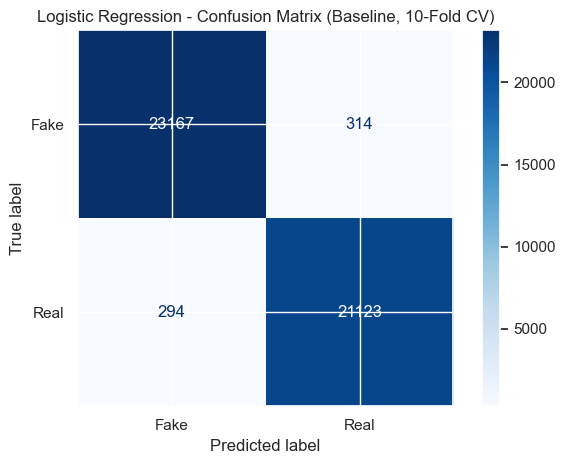

Saved: figures/fig_4_1_confusion_Logistic_Regression_baseline.png


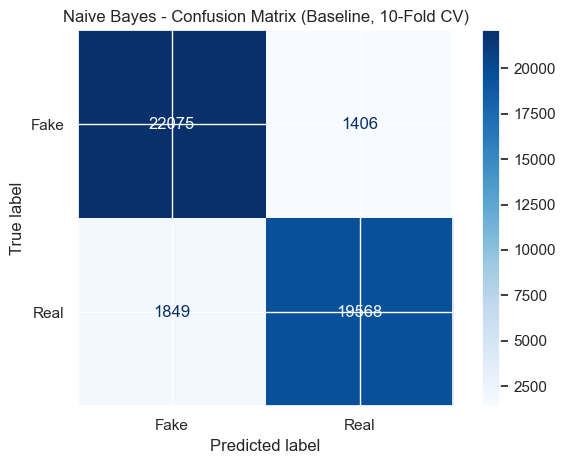

Saved: figures/fig_4_1_confusion_Naive_Bayes_baseline.png


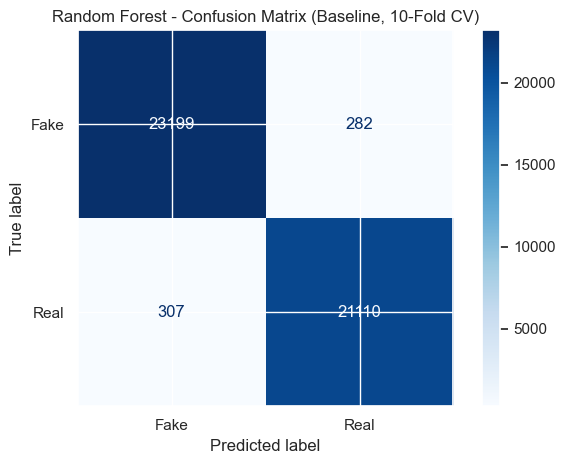

Saved: figures/fig_4_1_confusion_Random_Forest_baseline.png


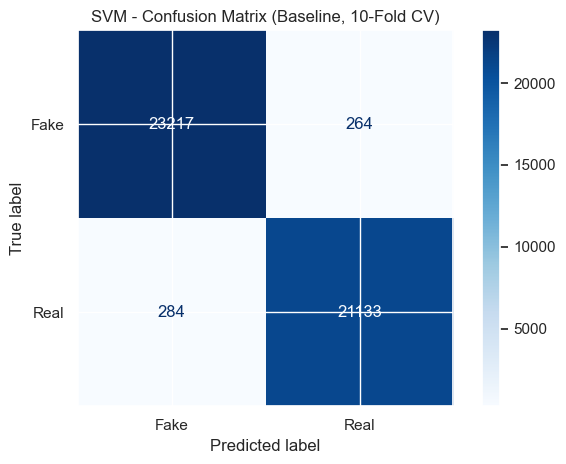

Saved: figures/fig_4_1_confusion_SVM_baseline.png


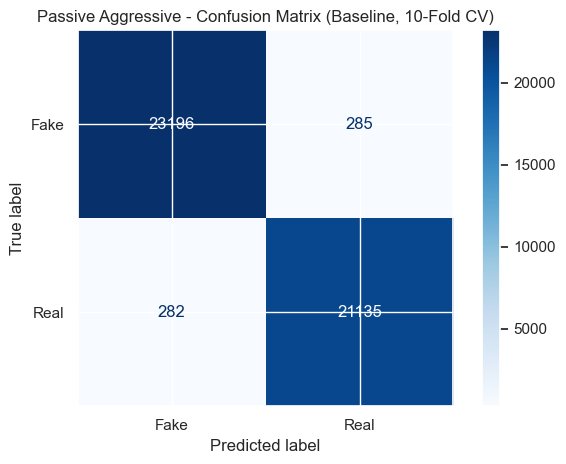

Saved: figures/fig_4_1_confusion_Passive_Aggressive_baseline.png


In [28]:
for name, model in baseline_tuned.items():
    cv_preds = cross_val_predict(model, X, y, cv=cv10, n_jobs=-1)
    cm = confusion_matrix(y, cv_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake","Real"])
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"{name} - Confusion Matrix (Baseline, 10-Fold CV)")
    plt.tight_layout()
    safe_name = name.replace(" ", "_")
    plt.savefig(f"figures/fig_4_1_confusion_{safe_name}_baseline.png", dpi=300)
    plt.show()
    print(f"Saved: figures/fig_4_1_confusion_{safe_name}_baseline.png")

## STEP 11: Baseline Comparison Chart (Figure 4.2)

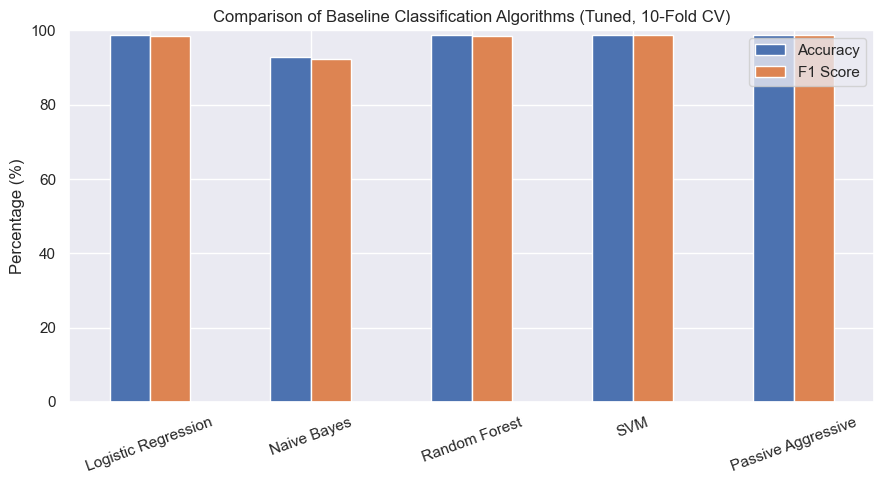

Saved: figures/fig_4_2_baseline_comparison.png


In [29]:
baseline_df[["Accuracy","F1 Score"]].astype(float).plot(kind="bar", figsize=(9,5))
plt.title("Comparison of Baseline Classification Algorithms (Tuned, 10-Fold CV)")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=20)
plt.ylim(0,100)
plt.tight_layout()
plt.savefig("figures/fig_4_2_baseline_comparison.png", dpi=300)
plt.show()
print("Saved: figures/fig_4_2_baseline_comparison.png")

---
# ANALYSIS 2: FEATURE FUSION (TF-IDF + Stylometric Features)

## STEP 12: Run Fused-Feature Tuning + 10-Fold Cross-Validation (Table 4.2)

In [30]:
fused_results, fused_tuned =   tune_and_validate(X_fused, "Fused Features")
fused_df = pd.DataFrame(fused_results).T
print("\n=== FUSED RESULTS (Table 4.2) ===")
fused_df

--- Tuning + 10-Fold CV: Fused Features ---
  Tuning Logistic Regression ...
    Logistic Regression: Test=99.02% F1=98.98% Train=99.64% Gap=0.61% -> Good fit
  Tuning Naive Bayes ...
    Naive Bayes: Test=92.86% F1=92.44% Train=93.06% Gap=0.19% -> Good fit
  Tuning Random Forest ...
    Random Forest: Test=99.06% F1=99.01% Train=100.00% Gap=0.94% -> Good fit
  Tuning SVM ...


c:\Users\ayush\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


    SVM: Test=99.15% F1=99.11% Train=99.81% Gap=0.66% -> Good fit
  Tuning Passive Aggressive ...


c:\Users\ayush\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


    Passive Aggressive: Test=99.08% F1=99.04% Train=99.73% Gap=0.64% -> Good fit

=== FUSED RESULTS (Table 4.2) ===


,Accuracy,F1 Score,Precision,Recall,Train Acc,Gap,Verdict
Logistic Regression,99.02223,98.975554,98.932012,99.019455,99.64,0.61,Good fit
Naive Bayes,92.861609,92.440918,93.397674,91.506742,93.06,0.19,Good fit
Random Forest,99.057868,99.010194,99.245138,98.776665,100.0,0.94,Good fit
SVM,99.146955,99.105398,99.159142,99.052137,99.81,0.66,Good fit
Passive Aggressive,99.082366,99.037698,99.07978,98.996115,99.73,0.64,Good fit


## STEP 13: Fused-Feature Confusion Matrices (Figure 4.3)

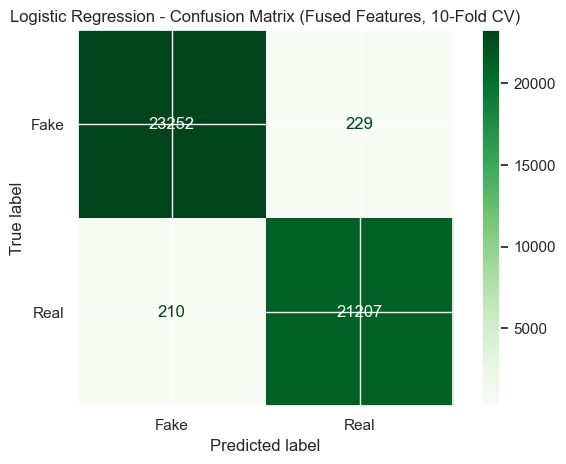

Saved: figures/fig_4_3_confusion_Logistic_Regression_fused.png


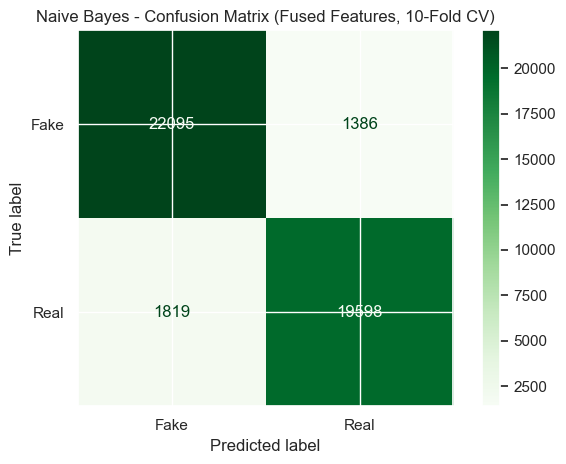

Saved: figures/fig_4_3_confusion_Naive_Bayes_fused.png


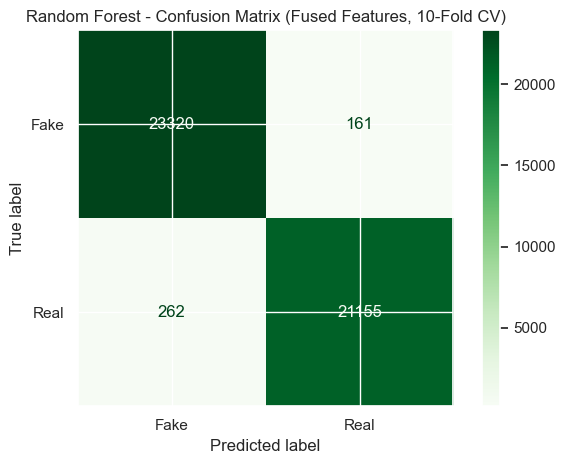

Saved: figures/fig_4_3_confusion_Random_Forest_fused.png


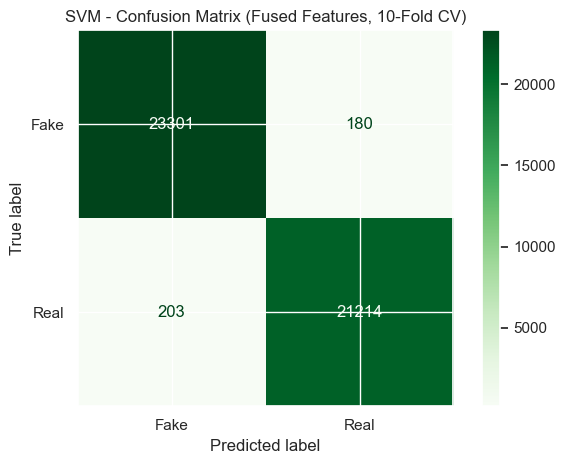

Saved: figures/fig_4_3_confusion_SVM_fused.png


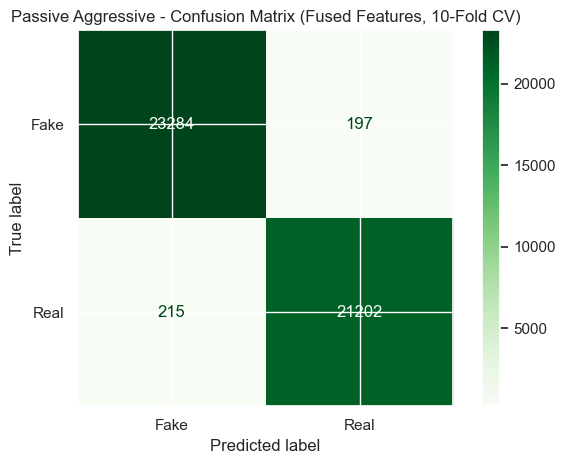

Saved: figures/fig_4_3_confusion_Passive_Aggressive_fused.png


In [31]:
for name, model in fused_tuned.items():
    cv_preds = cross_val_predict(model, X_fused, y, cv=cv10, n_jobs=-1)
    cm = confusion_matrix(y, cv_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake","Real"])
    disp.plot(cmap="Greens", values_format="d")
    plt.title(f"{name} - Confusion Matrix (Fused Features, 10-Fold CV)")
    plt.tight_layout()
    safe_name = name.replace(" ", "_")
    plt.savefig(f"figures/fig_4_3_confusion_{safe_name}_fused.png", dpi=300)
    plt.show()
    print(f"Saved: figures/fig_4_3_confusion_{safe_name}_fused.png")

## STEP 14: Fused-Feature Comparison Chart (Figure 4.4)

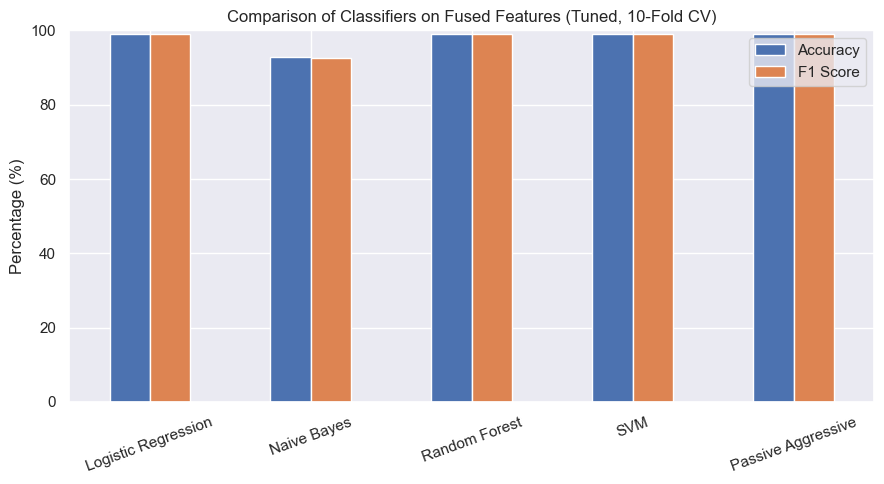

Saved: figures/fig_4_4_fused_comparison.png


In [32]:
fused_df[["Accuracy","F1 Score"]].astype(float).plot(kind="bar", figsize=(9,5))
plt.title("Comparison of Classifiers on Fused Features (Tuned, 10-Fold CV)")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=20)
plt.ylim(0,100)
plt.tight_layout()
plt.savefig("figures/fig_4_4_fused_comparison.png", dpi=300)
plt.show()
print("Saved: figures/fig_4_4_fused_comparison.png")

---
# ANALYSIS 3: PROPOSED WEIGHTED VOTING ENSEMBLE

## STEP 15: Build Ensemble (Auto-Selects Top 3) + 10-Fold Cross-Validation (Table 4.3)
Automatically finds whichever 3 tuned models scored highest on F1 in Step 12 (no hardcoded names), combines them into a weighted voting ensemble, and validates it with the same rigorous 10-fold cross-validation.

In [33]:
top_3_names = (
    pd.Series({name: fused_results[name]["F1 Score"] for name in fused_results})
    .sort_values(ascending=False).head(3).index.tolist()
)
print("Top 3 models selected:", top_3_names)

f1_scores = {name: fused_results[name]["F1 Score"] for name in top_3_names}
total = sum(f1_scores.values())
weights = [round(f1_scores[name]/total, 3) for name in top_3_names]
print("Ensemble weights:", dict(zip(top_3_names, weights)))

estimators = [(name, fused_tuned[name]) for name in top_3_names]
ensemble = VotingClassifier(estimators=estimators, voting="hard", weights=weights)

print("\nRunning 10-fold CV on the proposed ensemble...")
ens_scores = cross_validate(ensemble, X_fused, y, cv=cv10,
                             scoring=["accuracy","f1","precision","recall"],
                             return_train_score=True, n_jobs=-1)

train_acc = ens_scores["train_accuracy"].mean()*100
test_acc = ens_scores["test_accuracy"].mean()*100
gap = round(train_acc-test_acc, 2)
verdict = "Possible OVERFITTING" if gap > 5 else "Good fit"

fused_results["Proposed Ensemble"] = {
    "Accuracy": test_acc, "F1 Score": ens_scores["test_f1"].mean()*100,
    "Precision": ens_scores["test_precision"].mean()*100,
    "Recall": ens_scores["test_recall"].mean()*100,
    "Train Acc": round(train_acc,2), "Gap": gap, "Verdict": verdict
}
print(f"Proposed Ensemble: Train={train_acc:.2f}% Test={test_acc:.2f}% Gap={gap}% -> {verdict}")

final_df = pd.DataFrame(fused_results).T
print("\n=== FINAL COMPARISON TABLE (Tuned, 10-Fold CV) - Table 4.3 ===")
final_df

Top 3 models selected: ['SVM', 'Passive Aggressive', 'Random Forest']
Ensemble weights: {'SVM': np.float64(0.334), 'Passive Aggressive': np.float64(0.333), 'Random Forest': np.float64(0.333)}

Running 10-fold CV on the proposed ensemble...
Proposed Ensemble: Train=99.81% Test=99.19% Gap=0.62% -> Good fit

=== FINAL COMPARISON TABLE (Tuned, 10-Fold CV) - Table 4.3 ===


,Accuracy,F1 Score,Precision,Recall,Train Acc,Gap,Verdict
Logistic Regression,99.02223,98.975554,98.932012,99.019455,99.64,0.61,Good fit
Naive Bayes,92.861609,92.440918,93.397674,91.506742,93.06,0.19,Good fit
Random Forest,99.057868,99.010194,99.245138,98.776665,100.0,0.94,Good fit
SVM,99.146955,99.105398,99.159142,99.052137,99.81,0.66,Good fit
Passive Aggressive,99.082366,99.037698,99.07978,98.996115,99.73,0.64,Good fit
Proposed Ensemble,99.187047,99.147549,99.187294,99.108173,99.81,0.62,Good fit


## STEP 16: Proposed Ensemble Confusion Matrix (Figure 4.5)

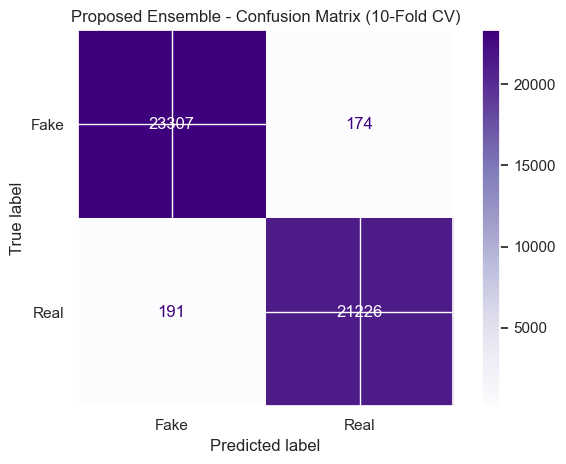

Saved: figures/fig_4_5_confusion_ensemble.png


In [34]:
ensemble_cv_preds = cross_val_predict(ensemble, X_fused, y, cv=cv10, n_jobs=-1)
ensemble_cm = confusion_matrix(y, ensemble_cv_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=ensemble_cm, display_labels=["Fake","Real"])
disp.plot(cmap="Purples", values_format="d")
plt.title("Proposed Ensemble - Confusion Matrix (10-Fold CV)")
plt.tight_layout()
plt.savefig("figures/fig_4_5_confusion_ensemble.png", dpi=300)
plt.show()
print("Saved: figures/fig_4_5_confusion_ensemble.png")

## STEP 17: Final Comparison Chart - Baseline vs Fused vs Ensemble (Figure 4.6)

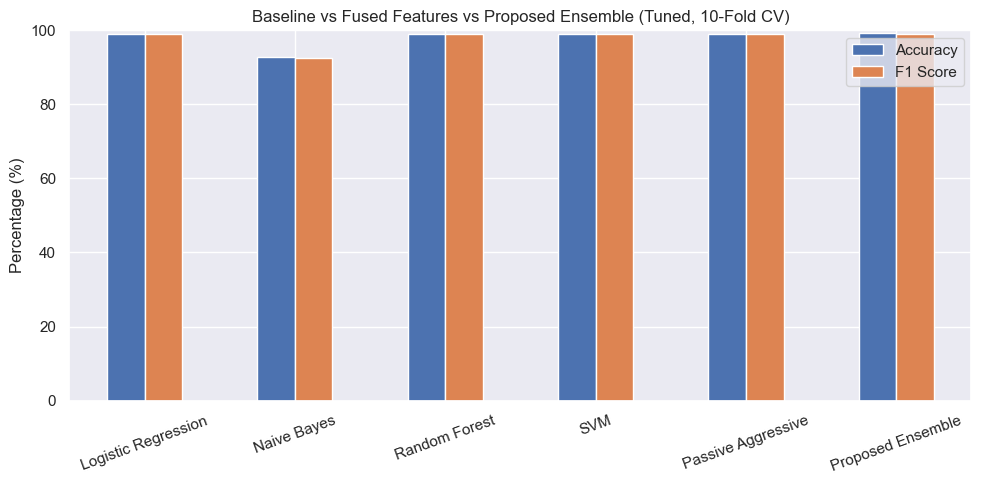

Saved: figures/fig_4_6_final_comparison.png


In [35]:
final_df[["Accuracy","F1 Score"]].astype(float).plot(kind="bar", figsize=(10,5))
plt.title("Baseline vs Fused Features vs Proposed Ensemble (Tuned, 10-Fold CV)")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=20)
plt.ylim(0,100)
plt.tight_layout()
plt.savefig("figures/fig_4_6_final_comparison.png", dpi=300)
plt.show()
print("Saved: figures/fig_4_6_final_comparison.png")

---
# FINAL VALIDATION: Error Metrics (Log Loss, Brier Score, MSE, RMSE)
Computed using 10-fold cross-validated probability predictions, so these numbers are just as rigorous as the accuracy/F1 results above.

## STEP 18: Error Metrics for All Tuned Models (Table 4.4)

In [36]:
error_models = {}
for name, model in fused_tuned.items():
    if name in ["SVM", "Passive Aggressive"]:
        error_models[name] = CalibratedClassifierCV(model, cv=3)
    else:
        error_models[name] = model

error_results = {}
for name, model in error_models.items():
    print(f"Computing error metrics for {name} (10-fold CV)...")
    probs = cross_val_predict(model, X_fused, y, cv=cv10, method="predict_proba", n_jobs=-1)[:, 1]

    ll = log_loss(y, probs)
    brier = brier_score_loss(y, probs)
    mse = mean_squared_error(y, probs)
    rmse = np.sqrt(mse)

    error_results[name] = {"Log Loss": round(ll,4), "Brier Score": round(brier,4),
                            "MSE": round(mse,4), "RMSE": round(rmse,4)}
    print(f"  {name}: Log Loss={ll:.4f}  Brier={brier:.4f}  MSE={mse:.4f}  RMSE={rmse:.4f}")

error_df = pd.DataFrame(error_results).T
print("\n=== FINAL ERROR METRICS TABLE (10-Fold CV) - Table 4.4 ===")
error_df

Computing error metrics for Logistic Regression (10-fold CV)...
  Logistic Regression: Log Loss=0.0385  Brier=0.0088  MSE=0.0088  RMSE=0.0939
Computing error metrics for Naive Bayes (10-fold CV)...
  Naive Bayes: Log Loss=0.1848  Brier=0.0536  MSE=0.0536  RMSE=0.2316
Computing error metrics for Random Forest (10-fold CV)...
  Random Forest: Log Loss=0.1283  Brier=0.0237  MSE=0.0237  RMSE=0.1539
Computing error metrics for SVM (10-fold CV)...
  SVM: Log Loss=0.0311  Brier=0.0074  MSE=0.0074  RMSE=0.0859
Computing error metrics for Passive Aggressive (10-fold CV)...
  Passive Aggressive: Log Loss=0.0326  Brier=0.0076  MSE=0.0076  RMSE=0.0869

=== FINAL ERROR METRICS TABLE (10-Fold CV) - Table 4.4 ===


,Log Loss,Brier Score,MSE,RMSE
Logistic Regression,0.0385,0.0088,0.0088,0.0939
Naive Bayes,0.1848,0.0536,0.0536,0.2316
Random Forest,0.1283,0.0237,0.0237,0.1539
SVM,0.0311,0.0074,0.0074,0.0859
Passive Aggressive,0.0326,0.0076,0.0076,0.0869


---
# SAVE FINAL MODELS FOR STREAMLIT APP
No duplicate training: the already-tuned models above are simply refit on the FULL dataset (standard practice - cross-validation estimates how well an approach generalizes, then the final deployed model uses all available data) and saved to disk for the Streamlit app to load instantly.

## STEP 19: Refit Final Models on Full Data and Save (for app.py)

In [37]:
print("Refitting final models on full dataset for deployment...")

# best baseline model, refit on full TF-IDF data
best_baseline_name = max(baseline_results, key=lambda n: baseline_results[n]["F1 Score"])
print(f"Best baseline model: {best_baseline_name}")
baseline_svm = baseline_tuned[best_baseline_name]
baseline_svm.fit(X, y)

# all 5 tuned fused models, refit on full fused data
fused_models_final = {}
for name, model in fused_tuned.items():
    model.fit(X_fused, y)
    fused_models_final[name] = model

# the ensemble, refit on full fused data
ensemble.fit(X_fused, y)

# save exactly the 5 files app.py expects
joblib.dump(tfidf, "saved_model/tfidf_vectorizer.pkl")
joblib.dump(scaler, "saved_model/stylometric_scaler.pkl")
joblib.dump(baseline_svm, "saved_model/baseline_svm.pkl")
joblib.dump(fused_models_final, "saved_model/fused_models.pkl")
joblib.dump(ensemble, "saved_model/proposed_ensemble.pkl")

print("""
Saved:
  saved_model/tfidf_vectorizer.pkl
  saved_model/stylometric_scaler.pkl
  saved_model/baseline_svm.pkl
  saved_model/fused_models.pkl
  saved_model/proposed_ensemble.pkl
""")
print("You can now run: python -m streamlit run app.py")

Refitting final models on full dataset for deployment...
Best baseline model: SVM

Saved:
  saved_model/tfidf_vectorizer.pkl
  saved_model/stylometric_scaler.pkl
  saved_model/baseline_svm.pkl
  saved_model/fused_models.pkl
  saved_model/proposed_ensemble.pkl

You can now run: python -m streamlit run app.py


## STEP 20: Compress Saved Models (for GitHub / Streamlit Deployment)

GitHub rejects any single file larger than 100 MB, and the tuned Random Forest 
inside the saved models can be large. This step reloads each saved model and 
re-saves it with joblib compression (compress=3).

Compression is lossless: the reloaded model has exactly the same trees, weights, 
and settings, so predictions and all reported results are identical. The only 
difference is a smaller file (and a slightly slower load time).

---
## Done!
This single notebook produced everything:
- All figures saved in `figures/` (300 DPI, ready for your Word thesis document)
- All final models saved in `saved_model/` (ready for your Streamlit app)
- No duplicate training - the same tuned models used for analysis were refit once at the end for deployment

Use `baseline_df`, `fused_df`, `final_df`, and `error_df` directly for your Chapter 4 tables, and the `figures/` folder for your Chapter 4 images.